In [1]:
import pyscf
from pyscf import fci,scf
import numpy as np
mol = pyscf.M(
    atom = 'O 0 0 0; O 0 0 1.1',  
    basis = 'sto-3g',
    symmetry = True,
    spin = 2,
    
)
myhf = mol.RHF().run()

# #
# # create an FCI solver based on the SCF object
# #
cisolver = pyscf.fci.FCI(myhf)
cie,civ=cisolver.kernel()
print(civ )
num_orbitals = myhf.mo_coeff.shape[1]
print(num_orbitals)
num_alpha_electrons, num_beta_electrons = mol.nelec
print(num_alpha_electrons,num_beta_electrons)
print(civ.shape)

# #
# # create an FCI solver based on the SCF object
# #

# myuhf = mol.UHF().run()
# cisolver = fci.FCI(myuhf)
# e,vec=cisolver.kernel()
# print(e,vec)

#
# # create an FCI solver based on the given orbitals and the num. electrons and
# # spin of the mol object
# #
# cisolver = pyscf.fci.FCI(mol, myhf.mo_coeff)
# print('E(FCI) = ', cisolver.kernel())

alpha_state=np.concatenate((np.ones(num_alpha_electrons),np.zeros(num_orbitals-num_alpha_electrons)),
                           axis=0)
beta_state=np.concatenate((np.ones(num_beta_electrons),np.zeros(num_orbitals-num_beta_electrons)),
                           axis=0)
print(alpha_state,beta_state)


# def generate_states(num_orbitals,num_electrons):
#     num_holes=num_orbitals-num_electrons
#     g_state=np.concatenate((np.ones(num_electrons),np.zeros(num_holes)),
#                            axis=0)
#     all=np.array(g_state)
#     max_excitements=np.min(num_electrons,num_holes)
#     for k in range(1,max_excitements+1):
#         for i in range(0,num_electrons):
#             for j in range(num_electrons,num_orbitals):




converged SCF energy = -147.590894030918
[[ 9.19854131e-02  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  4.92786279e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  2.20629094e-04 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-3.48841749e-05  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
10
9 7
(10, 120)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 0.] [1. 1. 1. 1. 1. 1. 1. 0. 0. 0.]


In [6]:
from itertools import combinations
from jax import numpy as jnp

def generate_states(num_orbitals,num_electrons):
    configs = []
    for indices in combinations(range(num_orbitals), num_electrons):
        box_config = [1 if i in indices else 0 for i in range(num_orbitals)]
        configs.append(box_config)
    return np.array(configs)

def generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,ci):
    # alpha_states=np.concatenate((np.ones(num_alpha_electrons),np.zeros(num_orbitals-num_alpha_electrons)),
    #                        axis=0)
    # beta_states=np.concatenate((np.ones(num_beta_electrons),np.zeros(num_orbitals-num_beta_electrons)),
    #                        axis=0)
    
    alpha_states=generate_states(num_orbitals,num_alpha_electrons)
    beta_states=generate_states(num_orbitals,num_beta_electrons)
    x=[]
    y=[]
    for i in range(0,len(alpha_states)):
        for j in range(0,len(beta_states)):
            y.append(ci[i,j])
            x.append(np.concatenate((alpha_states[i],beta_states[j]),axis=0))
    x=jnp.array(x)
    y=jnp.array(y)
    return x,y



# num_orbs = 10
# num_e = 7
# config_list = generate_states(num_orbs, num_e)

# print(generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ))



(Array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 0, 0],
       [1, 1, 1, ..., 0, 1, 0],
       ...,
       [0, 1, 1, ..., 1, 1, 1],
       [0, 1, 1, ..., 1, 1, 1],
       [0, 1, 1, ..., 1, 1, 1]], dtype=int32), Array([0.09198541, 0.        , 0.        , ..., 0.        , 0.        ,
       0.        ], dtype=float32))


In [8]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax
from jax import random
import matplotlib.pyplot as plt

class NN1(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(features=64)(x)  
        x = nn.relu(x)
        x = nn.Dense(features=1)(x)    
        return nn.tanh(x)              


def create_model(rng, input_shape):
    model = NN1()
    variables = model.init(rng, jnp.ones(input_shape))
    return model, variables

# Define the mean squared error (MSE) loss function
def mse_loss(params, apply_fn, x, y):
    preds = apply_fn({'params': params}, x)
    return jnp.mean((preds - y) ** 2)


@jax.jit
def train_step(state, batch):
    def loss_fn(params):
        x, y = batch
        loss = mse_loss(params, state.apply_fn, x, y)
        return loss
    grads = jax.grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss_fn(state.params)


def create_train_state(rng, model, variables):
    tx = optax.adam(learning_rate=0.001)
    return train_state.TrainState.create(apply_fn=model.apply, params=variables['params'], tx=tx)


# Check Neural network functions
# def generate_random_data(rng, num_samples, input_size):    
#     x = random.randint(rng, (num_samples, input_size), 0, 2)
#     y = random.uniform(rng, (num_samples, 1), float,-1, 1)
#     return x, y




Epoch 1, Loss: 0.06442862749099731
Epoch 2, Loss: 0.030823173001408577
Epoch 3, Loss: 0.018458591774106026
Epoch 4, Loss: 0.01153596118092537
Epoch 5, Loss: 0.008002294227480888
Epoch 6, Loss: 0.005971380043774843
Epoch 7, Loss: 0.004866556730121374
Epoch 8, Loss: 0.004223950672894716
Epoch 9, Loss: 0.003800990292802453
Epoch 10, Loss: 0.003529441077262163
Epoch 11, Loss: 0.0033407218288630247
Epoch 12, Loss: 0.0032042679376900196
Epoch 13, Loss: 0.003090935293585062
Epoch 14, Loss: 0.0030077584087848663
Epoch 15, Loss: 0.0029643122106790543
Epoch 16, Loss: 0.0029372430872172117
Epoch 17, Loss: 0.0029520310927182436
Epoch 18, Loss: 0.003005474805831909
Epoch 19, Loss: 0.0030797622166574
Epoch 20, Loss: 0.0031840107403695583
Epoch 21, Loss: 0.0032934017945080996
Epoch 22, Loss: 0.003454398363828659
Epoch 23, Loss: 0.0036140403244644403
Epoch 24, Loss: 0.003939002752304077
Epoch 25, Loss: 0.004270757548511028
Epoch 26, Loss: 0.004743014927953482
Epoch 27, Loss: 0.005293391644954681
Epoch

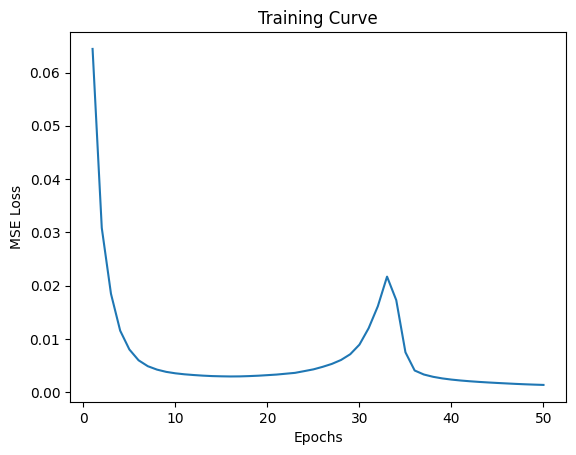

Training complete


In [18]:
# Main function
def main():
    rng = random.PRNGKey(7)
    
    x_train, y_train = generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ)
    input_size = 2*num_orbitals # Example input size
    num_samples = len(y_train) # Number of training samples
    
    model, variables = create_model(rng, (input_size,))
    state = create_train_state(rng, model, variables)
    
    # Training loop
    num_epochs = 50
    batch_size = 32
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for i in range(0, num_samples, batch_size):
            batch = (x_train[i:i+batch_size], y_train[i:i+batch_size])
            state, loss = train_step(state, batch)
            epoch_loss += loss
        
        average_epoch_loss = epoch_loss / (num_samples // batch_size)
        train_losses.append(average_epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {average_epoch_loss}")
    
    # Plotting the training curve
    plt.plot(range(1, num_epochs + 1), train_losses)
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training Curve')
    plt.show()
    #plt.plot(x_tra,y_train)
    print("Training complete")

if __name__ == "__main__":
    main()